# Brain Tumor MRI Classification — Graph Convolutional Network (GCN)

Superpixel-graph GCN, benchmarked against the ViT
CNN baseline.

## Table of Contents
1. [Setup & Configuration](#1-setup)
2. [File Index & Deduplication (16×16 Hash)](#2-dedup)
3. [Image → Graph Conversion (Superpixels + RAG)](#3-graph-construction)
4. [GCN Architecture](#4-gcn-model)
5. [Training Utilities](#5-training-utils)
6. [5-Fold Cross-Validation](#6-cv)
7. [Final Model — Train on Full Train+Val, Evaluate on Held-Out Test](#7-final-eval)
8. [Statistical Significance vs. CNN Baseline](#8-significance)
9. [Explainability — GNNExplainer / Node Importance](#9-xai)
10. [Results Summary & Saved Outputs](#10-summary)

## 1. Setup & Configuration

In [1]:
!pip install -q torch_geometric scikit-image

import os, json, time, copy, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool
from torch_geometric.explain import Explainer, GNNExplainer

from skimage.segmentation import slic
from skimage.graph import rag_mean_color

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_fscore_support, accuracy_score,
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from statsmodels.stats.contingency_tables import mcnemar

sns.set_style("whitegrid")

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

DATA_DIR = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset"
TRAIN_DIR = os.path.join(DATA_DIR, "Training")
TEST_DIR = os.path.join(DATA_DIR, "Testing")
CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]
NUM_CLASSES = len(CLASSES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

GRAPH_IMG_SIZE = (128, 128)   # images are resized to this before superpixel segmentation
                               # (smaller than the CNN's 224x224 — graph construction is
                               # CPU-bound, so this keeps preprocessing time reasonable
                               # without hurting region-level structure)
N_SEGMENTS = 75                # target superpixels per image (within the 50-150 guideline)
BATCH_SIZE = 32

PATIENCE = 6
MIN_EPOCHS = 50
MAX_EPOCHS = 60    
WEIGHT_DECAY = 1e-4
N_FOLDS = 5

CACHE_DIR = "/kaggle/working/graph_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.8 MB/s eta 0:00:00
Device: cuda


## 2. File Index & Deduplication (16×16 Hash)

Identical to the CNN pipeline: 16×16 perceptual hash, applied to train/val/test,
within-split dedup then cross-split leakage removal. Reusing the exact same
split logic guarantees the CNN-vs-GCN comparison is on the same data.

In [2]:
def build_index(root_dir, split_name):
    records = []
    for cls in CLASSES:
        cls_dir = os.path.join(root_dir, cls)
        for fname in os.listdir(cls_dir):
            records.append({"filepath": os.path.join(cls_dir, fname), "class": cls, "split": split_name})
    return pd.DataFrame(records)

def phash_16x16(filepath):
    img = Image.open(filepath).convert("L").resize((16, 16), Image.LANCZOS)
    pixels = np.asarray(img, dtype=np.float32)
    avg = pixels.mean()
    bits = (pixels > avg).flatten()
    return "".join("1" if b else "0" for b in bits)

def dedup_within_split(df, split_name):
    before = len(df)
    df_sorted = df.sort_values("filepath").reset_index(drop=True)
    df_deduped = df_sorted.drop_duplicates(subset="phash16", keep="first").reset_index(drop=True)
    print(f"{split_name}: removed {before - len(df_deduped)} within-split duplicate(s) "
          f"({before} -> {len(df_deduped)})")
    return df_deduped

def remove_leakage(df_reference, df_target, ref_name, target_name):
    ref_hashes = set(df_reference["phash16"])
    before = len(df_target)
    mask = df_target["phash16"].isin(ref_hashes)
    df_clean = df_target[~mask].reset_index(drop=True)
    print(f"{ref_name} -> {target_name}: removed {mask.sum()} leaked image(s) ({before} -> {len(df_clean)})")
    return df_clean

df_train_full = build_index(TRAIN_DIR, "train")
df_test_full = build_index(TEST_DIR, "test")
df_val, df_test = train_test_split(df_test_full, test_size=0.5, stratify=df_test_full["class"], random_state=SEED)
df_train = df_train_full.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

for name, d in [("train", "train"), ("val", "val"), ("test", "test")]:
    pass

df_train["phash16"] = df_train["filepath"].apply(phash_16x16)
df_val["phash16"] = df_val["filepath"].apply(phash_16x16)
df_test["phash16"] = df_test["filepath"].apply(phash_16x16)

df_train = dedup_within_split(df_train, "train")
df_val = dedup_within_split(df_val, "val")
df_test = dedup_within_split(df_test, "test")

df_val = remove_leakage(df_train, df_val, "train", "val")
df_test = remove_leakage(df_train, df_test, "train", "test")
df_test = remove_leakage(df_val, df_test, "val", "test")

df_train = df_train.drop(columns=["phash16"]).reset_index(drop=True)
df_val = df_val.drop(columns=["phash16"]).reset_index(drop=True)
df_test = df_test.drop(columns=["phash16"]).reset_index(drop=True)

# Combined pool for 5-fold CV (test stays fully held out, untouched)
df_trainval = pd.concat([df_train, df_val], ignore_index=True)

print("\nFinal sizes -> train+val (for CV):", df_trainval.shape, "| held-out test:", df_test.shape)
print(df_trainval["class"].value_counts().reindex(CLASSES))

train: removed 559 within-split duplicate(s) (5600 -> 5041)
val: removed 30 within-split duplicate(s) (800 -> 770)
test: removed 37 within-split duplicate(s) (800 -> 763)
train -> val: removed 159 leaked image(s) (770 -> 611)
train -> test: removed 169 leaked image(s) (763 -> 594)
val -> test: removed 19 leaked image(s) (594 -> 575)

Final sizes -> train+val (for CV): (5652, 3) | held-out test: (575, 3)
class
glioma        1580
meningioma    1528
notumor        997
pituitary     1547
Name: count, dtype: int64


## 3. Image → Graph Conversion (Superpixels + RAG)

Each image is segmented into ~75 superpixels with SLIC. Each superpixel
becomes a graph node; adjacent superpixels (sharing a border) are connected
via a Region Adjacency Graph (RAG). Because building ~9,000 graphs is
CPU-heavy, the result is cached to disk once and reloaded on every later run.

**Node features (5-dim):** mean intensity, std intensity, normalized centroid
x, normalized centroid y, fraction of image area.
**Edge weight:** inverse of mean-intensity difference between adjacent
regions — higher weight for more similar (more likely same-tissue) neighbors.

In [3]:
def image_to_graph(filepath, label_idx):
    img = Image.open(filepath).convert("L").resize(GRAPH_IMG_SIZE, Image.LANCZOS)
    img_arr = np.asarray(img, dtype=np.float32) / 255.0
    img_rgb = np.stack([img_arr] * 3, axis=-1)  # slic expects a 3-channel image

    segments = slic(img_rgb, n_segments=N_SEGMENTS, compactness=10, start_label=0, channel_axis=-1)
    n_nodes = segments.max() + 1
    H, W = img_arr.shape

    node_features = np.zeros((n_nodes, 5), dtype=np.float32)
    for seg_id in range(n_nodes):
        mask = segments == seg_id
        ys, xs = np.where(mask)
        pixels = img_arr[mask]
        node_features[seg_id] = [
            pixels.mean(),
            pixels.std(),
            xs.mean() / W,
            ys.mean() / H,
            mask.sum() / (H * W),
        ]

    rag = rag_mean_color(img_rgb, segments)
    edge_index, edge_weight = [], []
    for u, v, data in rag.edges(data=True):
        diff = abs(node_features[u, 0] - node_features[v, 0])
        w = 1.0 / (1.0 + diff)
        edge_index.append([u, v]); edge_weight.append(w)
        edge_index.append([v, u]); edge_weight.append(w)  # undirected -> both directions

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_weight = torch.tensor(edge_weight, dtype=torch.float32)
    x = torch.tensor(node_features, dtype=torch.float32)
    y = torch.tensor([label_idx], dtype=torch.long)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_weight, y=y, segments=segments, filepath=filepath)


def build_graph_list(df, cache_name):
    cache_path = os.path.join(CACHE_DIR, cache_name)
    if os.path.exists(cache_path):
        print(f"Loading cached graphs: {cache_path}")
        return torch.load(cache_path)

    print(f"Building {len(df)} graphs for {cache_name} (this can take a while)...")
    graphs = []
    for i, row in df.iterrows():
        label_idx = CLASS_TO_IDX[row["class"]]
        g = image_to_graph(row["filepath"], label_idx)
        graphs.append(g)
        if (i + 1) % 500 == 0:
            print(f"  {i + 1}/{len(df)} done")
    torch.save(graphs, cache_path)
    print(f"Cached to {cache_path}")
    return graphs


graphs_trainval = build_graph_list(df_trainval, "trainval_graphs.pt")
graphs_test = build_graph_list(df_test, "test_graphs.pt")

print(f"\nAvg nodes/graph (train+val): {np.mean([g.x.shape[0] for g in graphs_trainval]):.1f}")
print(f"Avg edges/graph (train+val): {np.mean([g.edge_index.shape[1] for g in graphs_trainval]):.1f}")

Building 5652 graphs for trainval_graphs.pt (this can take a while)...
  500/5652 done
  1000/5652 done
  1500/5652 done
  2000/5652 done
  2500/5652 done
  3000/5652 done
  3500/5652 done
  4000/5652 done
  4500/5652 done
  5000/5652 done
  5500/5652 done
Cached to /kaggle/working/graph_cache/trainval_graphs.pt
Building 575 graphs for test_graphs.pt (this can take a while)...
  500/575 done
Cached to /kaggle/working/graph_cache/test_graphs.pt

Avg nodes/graph (train+val): 61.3
Avg edges/graph (train+val): 309.0


## 4. GCN Architecture

Three `GCNConv` layers with batch norm + dropout, then a concatenation of
global mean-pool and global max-pool (captures both average and most-salient
node signal), followed by a linear classification head.

In [4]:
class BrainTumorGCN(nn.Module):
    def __init__(self, in_channels=5, hidden_channels=64, num_classes=NUM_CLASSES, dropout=0.4):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.bn3 = nn.BatchNorm1d(hidden_channels)
        self.dropout = dropout

        self.classifier = nn.Sequential(
            nn.Linear(hidden_channels * 2, 128),  # *2 for mean+max pool concat
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x, edge_index, edge_weight, batch):
        x = F.relu(self.bn1(self.conv1(x, edge_index, edge_weight)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.bn2(self.conv2(x, edge_index, edge_weight)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.bn3(self.conv3(x, edge_index, edge_weight)))

        x_mean = global_mean_pool(x, batch)
        x_max = global_max_pool(x, batch)
        x = torch.cat([x_mean, x_max], dim=1)

        return self.classifier(x)


model_probe = BrainTumorGCN().to(device)
print(model_probe)
print(f"Total params: {sum(p.numel() for p in model_probe.parameters()):,}")

BrainTumorGCN(
  (conv1): GCNConv(5, 64)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): GCNConv(64, 64)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): GCNConv(64, 64)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=128, out_features=4, bias=True)
  )
)
Total params: 26,116


## 5. Training Utilities

Same `EarlyStopping` design as the CNN notebook: won't stop before
`MIN_EPOCHS`, stops after `PATIENCE` epochs without `val_loss` improvement,
restores best-val_loss weights. `ReduceLROnPlateau` halves LR on plateaus.

In [5]:
class EarlyStopping:
    def __init__(self, patience, min_epochs, restore_best=True):
        self.patience = patience
        self.min_epochs = min_epochs
        self.restore_best = restore_best
        self.best_score = None
        self.best_state = None
        self.counter = 0
        self.should_stop = False

    def step(self, epoch, value, model):
        improved = self.best_score is None or value < self.best_score
        if improved:
            self.best_score = value
            self.counter = 0
            if self.restore_best:
                self.best_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
        if epoch >= self.min_epochs and self.counter >= self.patience:
            self.should_stop = True
        return improved

    def restore(self, model):
        if self.restore_best and self.best_state is not None:
            model.load_state_dict(self.best_state)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs
        correct += (out.argmax(1) == batch.y).sum().item()
        total += batch.num_graphs
    return total_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = criterion(out, batch.y)
        total_loss += loss.item() * batch.num_graphs
        correct += (out.argmax(1) == batch.y).sum().item()
        total += batch.num_graphs
    return total_loss / total, correct / total


def train_gcn(model, train_loader, val_loader, class_weights, min_epochs, max_epochs, patience, tag=""):
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-6)
    early_stopping = EarlyStopping(patience=patience, min_epochs=min_epochs)
    log = []

    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        scheduler.step(val_loss)
        early_stopping.step(epoch, val_loss, model)

        log.append({"epoch": epoch, "train_loss": train_loss, "train_acc": train_acc,
                     "val_loss": val_loss, "val_acc": val_acc})
        print(f"{tag} epoch {epoch}/{max_epochs} - loss: {train_loss:.4f} acc: {train_acc:.4f} "
              f"- val_loss: {val_loss:.4f} val_acc: {val_acc:.4f}")

        if early_stopping.should_stop:
            print(f"{tag} EarlyStopping at epoch {epoch} (no improvement for {patience} epochs past min_epochs={min_epochs})")
            break

    early_stopping.restore(model)
    return model, log

## 6. 5-Fold Cross-Validation

Stratified 5-fold split on `train+val` only — the held-out test set is never
touched here. Each fold trains a fresh GCN from scratch under the same
min-50/max-100/patience-6 policy. Results are reported as mean ± std, as
required for the final performance comparison.

In [6]:
labels_trainval = np.array([g.y.item() for g in graphs_trainval])
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

fold_results = []
fold_models_dir = "/kaggle/working/gcn_fold_models"
os.makedirs(fold_models_dir, exist_ok=True)

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels_trainval)), labels_trainval), start=1):
    print(f"\n========== Fold {fold}/{N_FOLDS} ==========")
    train_graphs_fold = [graphs_trainval[i] for i in train_idx]
    val_graphs_fold = [graphs_trainval[i] for i in val_idx]

    fold_train_labels = labels_trainval[train_idx]
    class_weights_arr = compute_class_weight(class_weight="balanced", classes=np.arange(NUM_CLASSES), y=fold_train_labels)
    class_weights = torch.tensor(class_weights_arr, dtype=torch.float32).to(device)

    train_loader = PyGDataLoader(train_graphs_fold, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = PyGDataLoader(val_graphs_fold, batch_size=BATCH_SIZE, shuffle=False)

    fold_model = BrainTumorGCN().to(device)
    fold_model, fold_log = train_gcn(
        fold_model, train_loader, val_loader, class_weights,
        min_epochs=MIN_EPOCHS, max_epochs=MAX_EPOCHS, patience=PATIENCE, tag=f"[fold {fold}]"
    )

    val_loss, val_acc = validate(fold_model, val_loader, nn.CrossEntropyLoss(weight=class_weights), device)

    y_val_true, y_val_pred = [], []
    fold_model.eval()
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = fold_model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            y_val_pred.extend(out.argmax(1).cpu().numpy())
            y_val_true.extend(batch.y.cpu().numpy())

    precision, recall, f1, _ = precision_recall_fscore_support(y_val_true, y_val_pred, average="macro")
    fold_results.append({"fold": fold, "val_acc": val_acc, "val_loss": val_loss,
                          "precision_macro": precision, "recall_macro": recall, "f1_macro": f1})

    torch.save(fold_model.state_dict(), os.path.join(fold_models_dir, f"GCN_fold{fold}.pth"))
    pd.DataFrame(fold_log).to_csv(f"GCN_fold{fold}_history.csv", index=False)

cv_df = pd.DataFrame(fold_results)
cv_df.to_csv("GCN_5fold_cv_results.csv", index=False)
print("\n=== 5-Fold CV Results ===")
print(cv_df)
print("\n=== Mean ± Std across folds ===")
for col in ["val_acc", "precision_macro", "recall_macro", "f1_macro"]:
    print(f"{col}: {cv_df[col].mean():.4f} ± {cv_df[col].std():.4f}")


========== Fold 1/5 ==========


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


[fold 1] epoch 1/60 - loss: 1.1070 acc: 0.5023 - val_loss: 0.8699 val_acc: 0.7011
[fold 1] epoch 2/60 - loss: 0.9095 acc: 0.6317 - val_loss: 0.8034 val_acc: 0.7091
[fold 1] epoch 3/60 - loss: 0.8694 acc: 0.6523 - val_loss: 0.7520 val_acc: 0.7056
[fold 1] epoch 4/60 - loss: 0.8336 acc: 0.6689 - val_loss: 0.7386 val_acc: 0.7356
[fold 1] epoch 5/60 - loss: 0.8155 acc: 0.6711 - val_loss: 0.7242 val_acc: 0.7365
[fold 1] epoch 6/60 - loss: 0.7845 acc: 0.6868 - val_loss: 0.6750 val_acc: 0.7480
[fold 1] epoch 7/60 - loss: 0.7655 acc: 0.6894 - val_loss: 0.7018 val_acc: 0.7356
[fold 1] epoch 8/60 - loss: 0.7531 acc: 0.6901 - val_loss: 0.6539 val_acc: 0.7692
[fold 1] epoch 9/60 - loss: 0.7406 acc: 0.7087 - val_loss: 0.6520 val_acc: 0.7515
[fold 1] epoch 10/60 - loss: 0.7364 acc: 0.7036 - val_loss: 0.6346 val_acc: 0.7577
[fold 1] epoch 11/60 - loss: 0.7146 acc: 0.7136 - val_loss: 0.6350 val_acc: 0.7639
[fold 1] epoch 12/60 - loss: 0.7199 acc: 0.7096 - val_loss: 0.6237 val_acc: 0.7745
[fold 1] epoc

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


[fold 2] epoch 1/60 - loss: 1.1098 acc: 0.4910 - val_loss: 0.9006 val_acc: 0.6216
[fold 2] epoch 2/60 - loss: 0.9350 acc: 0.6123 - val_loss: 0.8396 val_acc: 0.6808
[fold 2] epoch 3/60 - loss: 0.8677 acc: 0.6525 - val_loss: 0.7922 val_acc: 0.6932
[fold 2] epoch 4/60 - loss: 0.8393 acc: 0.6627 - val_loss: 0.7659 val_acc: 0.6976
[fold 2] epoch 5/60 - loss: 0.8309 acc: 0.6653 - val_loss: 0.7500 val_acc: 0.7038
[fold 2] epoch 6/60 - loss: 0.8064 acc: 0.6797 - val_loss: 0.7139 val_acc: 0.7268
[fold 2] epoch 7/60 - loss: 0.7942 acc: 0.6888 - val_loss: 0.7462 val_acc: 0.7153
[fold 2] epoch 8/60 - loss: 0.7793 acc: 0.6848 - val_loss: 0.6770 val_acc: 0.7294
[fold 2] epoch 9/60 - loss: 0.7584 acc: 0.7074 - val_loss: 0.6657 val_acc: 0.7356
[fold 2] epoch 10/60 - loss: 0.7426 acc: 0.7100 - val_loss: 0.6563 val_acc: 0.7542
[fold 2] epoch 11/60 - loss: 0.7231 acc: 0.7120 - val_loss: 0.6652 val_acc: 0.7507
[fold 2] epoch 12/60 - loss: 0.7315 acc: 0.7142 - val_loss: 0.6577 val_acc: 0.7383
[fold 2] epoc

...

[fold 3] epoch 1/60 - loss: 1.1053 acc: 0.5117 - val_loss: 0.9011 val_acc: 0.6699
[fold 3] epoch 2/60 - loss: 0.9033 acc: 0.6274 - val_loss: 0.7874 val_acc: 0.6947
[fold 3] epoch 3/60 - loss: 0.8467 acc: 0.6594 - val_loss: 0.7701 val_acc: 0.7071
[fold 3] epoch 4/60 - loss: 0.8463 acc: 0.6634 - val_loss: 0.7368 val_acc: 0.7177
[fold 3] epoch 5/60 - loss: 0.8024 acc: 0.6875 - val_loss: 0.7104 val_acc: 0.7265
[fold 3] epoch 6/60 - loss: 0.7797 acc: 0.6937 - val_loss: 0.6886 val_acc: 0.7389
[fold 3] epoch 7/60 - loss: 0.7855 acc: 0.6855 - val_loss: 0.6616 val_acc: 0.7575
[fold 3] epoch 8/60 - loss: 0.7618 acc: 0.6990 - val_loss: 0.6787 val_acc: 0.7478
[fold 3] epoch 9/60 - loss: 0.7451 acc: 0.7090 - val_loss: 0.7307 val_acc: 0.7230
[fold 3] epoch 10/60 - loss: 0.7308 acc: 0.7107 - val_loss: 0.6471 val_acc: 0.7522
[fold 3] epoch 11/60 - loss: 0.7359 acc: 0.7059 - val_loss: 0.6285 val_acc: 0.7504
[fold 3] epoch 12/60 - loss: 0.7221 acc: 0.7169 - val_loss: 0.6479 val_acc: 0.7522
[fold 3] epoc

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


[fold 4] epoch 1/60 - loss: 1.1293 acc: 0.4876 - val_loss: 0.9056 val_acc: 0.6611
[fold 4] epoch 2/60 - loss: 0.9205 acc: 0.6207 - val_loss: 0.8298 val_acc: 0.6681
[fold 4] epoch 3/60 - loss: 0.8606 acc: 0.6575 - val_loss: 0.7782 val_acc: 0.7027
[fold 4] epoch 4/60 - loss: 0.8280 acc: 0.6729 - val_loss: 0.7636 val_acc: 0.7071
[fold 4] epoch 5/60 - loss: 0.8056 acc: 0.6811 - val_loss: 0.7458 val_acc: 0.7195
[fold 4] epoch 6/60 - loss: 0.7732 acc: 0.6999 - val_loss: 0.7326 val_acc: 0.7159
[fold 4] epoch 7/60 - loss: 0.7685 acc: 0.6939 - val_loss: 0.6976 val_acc: 0.7195
[fold 4] epoch 8/60 - loss: 0.7458 acc: 0.7050 - val_loss: 0.6768 val_acc: 0.7327
[fold 4] epoch 9/60 - loss: 0.7390 acc: 0.7063 - val_loss: 0.6677 val_acc: 0.7496
[fold 4] epoch 10/60 - loss: 0.7198 acc: 0.7247 - val_loss: 0.6599 val_acc: 0.7389
[fold 4] epoch 11/60 - loss: 0.7204 acc: 0.7203 - val_loss: 0.6731 val_acc: 0.7407
[fold 4] epoch 12/60 - loss: 0.7067 acc: 0.7262 - val_loss: 0.6615 val_acc: 0.7345
[fold 4] epoc

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


[fold 5] epoch 1/60 - loss: 1.0889 acc: 0.5299 - val_loss: 0.8842 val_acc: 0.6354
[fold 5] epoch 2/60 - loss: 0.8934 acc: 0.6373 - val_loss: 0.8196 val_acc: 0.6823
[fold 5] epoch 3/60 - loss: 0.8590 acc: 0.6634 - val_loss: 0.7838 val_acc: 0.6947
[fold 5] epoch 4/60 - loss: 0.8273 acc: 0.6692 - val_loss: 0.7777 val_acc: 0.6991
[fold 5] epoch 5/60 - loss: 0.8035 acc: 0.6864 - val_loss: 0.7583 val_acc: 0.7230
[fold 5] epoch 6/60 - loss: 0.7811 acc: 0.6946 - val_loss: 0.7307 val_acc: 0.7372
[fold 5] epoch 7/60 - loss: 0.7879 acc: 0.6844 - val_loss: 0.6947 val_acc: 0.7442
[fold 5] epoch 8/60 - loss: 0.7584 acc: 0.7043 - val_loss: 0.7512 val_acc: 0.7274
[fold 5] epoch 9/60 - loss: 0.7485 acc: 0.6988 - val_loss: 0.6840 val_acc: 0.7487
[fold 5] epoch 10/60 - loss: 0.7312 acc: 0.7121 - val_loss: 0.6856 val_acc: 0.7381
[fold 5] epoch 11/60 - loss: 0.7139 acc: 0.7105 - val_loss: 0.6880 val_acc: 0.7451
[fold 5] epoch 12/60 - loss: 0.7231 acc: 0.7145 - val_loss: 0.6781 val_acc: 0.7531
[fold 5] epoc

## 7. Final Model — Train on Full Train+Val, Evaluate on Held-Out Test

The 5-fold CV above validates the approach's stability. For the headline
number to compare against your 94%+ CNN, train one final model on the full
`train+val` pool and evaluate once, cleanly, on the untouched test set.

In [7]:
class_weights_arr = compute_class_weight(class_weight="balanced", classes=np.arange(NUM_CLASSES), y=labels_trainval)
class_weights_final = torch.tensor(class_weights_arr, dtype=torch.float32).to(device)

# carve out a small internal validation slice from train+val for early stopping
final_train_idx, final_val_idx = train_test_split(
    np.arange(len(graphs_trainval)), test_size=0.1, stratify=labels_trainval, random_state=SEED
)
final_train_graphs = [graphs_trainval[i] for i in final_train_idx]
final_val_graphs = [graphs_trainval[i] for i in final_val_idx]

final_train_loader = PyGDataLoader(final_train_graphs, batch_size=BATCH_SIZE, shuffle=True)
final_val_loader = PyGDataLoader(final_val_graphs, batch_size=BATCH_SIZE, shuffle=False)
test_loader = PyGDataLoader(graphs_test, batch_size=BATCH_SIZE, shuffle=False)

final_model = BrainTumorGCN().to(device)
final_model, final_log = train_gcn(
    final_model, final_train_loader, final_val_loader, class_weights_final,
    min_epochs=MIN_EPOCHS, max_epochs=MAX_EPOCHS, patience=PATIENCE, tag="[final]"
)

pd.DataFrame(final_log).to_csv("GCN_final_history.csv", index=False)
torch.save(final_model.state_dict(), "GCN_best_model.pth")
print("Saved GCN_best_model.pth and GCN_final_history.csv")

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


[final] epoch 1/60 - loss: 1.0875 acc: 0.5226 - val_loss: 0.8053 val_acc: 0.7155
[final] epoch 2/60 - loss: 0.9219 acc: 0.6193 - val_loss: 0.7177 val_acc: 0.7403
[final] epoch 3/60 - loss: 0.8690 acc: 0.6557 - val_loss: 0.7128 val_acc: 0.7297
[final] epoch 4/60 - loss: 0.8382 acc: 0.6718 - val_loss: 0.6638 val_acc: 0.7438
[final] epoch 5/60 - loss: 0.8111 acc: 0.6750 - val_loss: 0.6631 val_acc: 0.7615
[final] epoch 6/60 - loss: 0.7887 acc: 0.6832 - val_loss: 0.6341 val_acc: 0.7721
[final] epoch 7/60 - loss: 0.7657 acc: 0.6984 - val_loss: 0.6061 val_acc: 0.7721
[final] epoch 8/60 - loss: 0.7664 acc: 0.6919 - val_loss: 0.6117 val_acc: 0.7703
[final] epoch 9/60 - loss: 0.7403 acc: 0.7112 - val_loss: 0.6070 val_acc: 0.7756
[final] epoch 10/60 - loss: 0.7418 acc: 0.7002 - val_loss: 0.5739 val_acc: 0.7809
[final] epoch 11/60 - loss: 0.7306 acc: 0.7084 - val_loss: 0.5682 val_acc: 0.7898
[final] epoch 12/60 - loss: 0.7174 acc: 0.7102 - val_loss: 0.5933 val_acc: 0.7686
[final] epoch 13/60 - los

GCN held-out test accuracy: 0.7513
              precision    recall  f1-score   support

      glioma       0.79      0.55      0.65       176
  meningioma       0.64      0.63      0.63       142
     notumor       0.62      0.97      0.75        58
   pituitary       0.86      0.95      0.90       199

    accuracy                           0.75       575
   macro avg       0.73      0.77      0.73       575
weighted avg       0.76      0.75      0.74       575



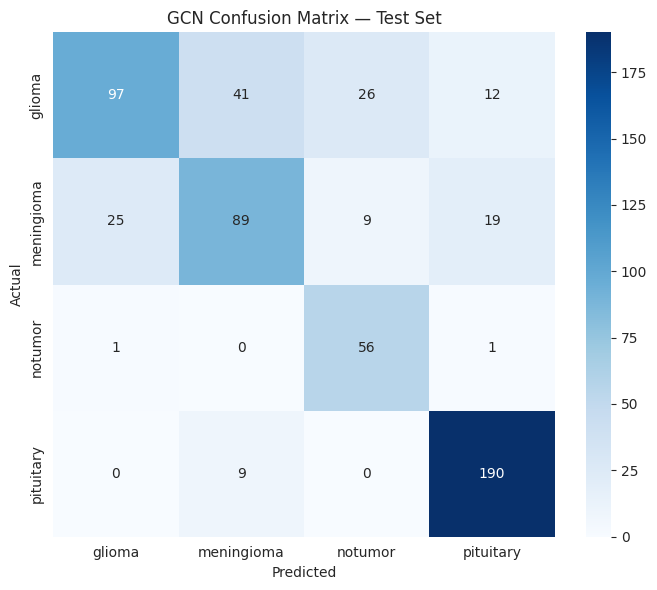


CNN baseline: 0.9400  |  GCN: 0.7513  |  Delta: -0.1887


In [8]:
@torch.no_grad()
def predict_all_pyg(model, loader, device):
    model.eval()
    all_probs, all_labels = [], []
    for batch in loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        probs = F.softmax(out, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(batch.y.cpu().numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)


gcn_test_probs, gcn_y_true = predict_all_pyg(final_model, test_loader, device)
gcn_y_pred = np.argmax(gcn_test_probs, axis=1)

# test_loader has shuffle=False, so this list is in the same order as
# gcn_y_true/gcn_y_pred above -- lets us align with another model's
# predictions by filepath instead of assuming matching row order.
gcn_filepaths = [g.filepath for g in graphs_test]

gcn_test_acc = accuracy_score(gcn_y_true, gcn_y_pred)
report_text = classification_report(gcn_y_true, gcn_y_pred, target_names=CLASSES)
report_dict = classification_report(gcn_y_true, gcn_y_pred, target_names=CLASSES, output_dict=True)
print(f"GCN held-out test accuracy: {gcn_test_acc:.4f}")
print(report_text)

with open("GCN_classification_report.txt", "w") as f: f.write(report_text)
with open("GCN_classification_report.json", "w") as f: json.dump(report_dict, f, indent=2)

np.save("GCN_test_predictions.npy", gcn_y_pred)   # save raw predictions for future significance tests
np.save("GCN_test_labels.npy", gcn_y_true)

cm = confusion_matrix(gcn_y_true, gcn_y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("GCN Confusion Matrix — Test Set")
plt.tight_layout(); plt.show()

CNN_BASELINE_ACC = 0.94  # <-- replace with your exact ViT test accuracy
print(f"\nCNN baseline: {CNN_BASELINE_ACC:.4f}  |  GCN: {gcn_test_acc:.4f}  |  "
      f"Delta: {gcn_test_acc - CNN_BASELINE_ACC:+.4f}")

## 8. Statistical Significance vs. CNN Baseline

McNemar's test on paired predictions (same test images, CNN vs. GCN) — the
correct test for two classifiers evaluated on the identical sample set, as
required by §6.4. **This cell needs your ViT's raw per-image predictions on
this exact (deduplicated) test set** — not just the reported accuracy number,
since the test is paired.

If you don't have `vit_test_predictions.csv` saved from your ViT notebook
yet, that notebook already has a cell that saves it:

```python
pred_df = pd.DataFrame({
    "filepath": df_test["filepath"].values,
    "y_true": np.array(all_labels),
    "y_pred": np.array(all_preds),
})
pred_df.to_csv("vit_test_predictions.csv", index=False)
```

Then upload `vit_test_predictions.csv` to this notebook's input and run the
cell below. The `filepath` column lets this cell align the two notebooks'
predictions by image rather than assuming matching row order (the ViT and
GCN notebooks each ran their own dedup pass, so row order isn't guaranteed
to match even though the logic is identical).


In [9]:
CNN_PREDS_PATH = "/kaggle/input/notebooks/meghlabiswas1/vit-cse475/vit_test_predictions.csv"  # <-- update path

if os.path.exists(CNN_PREDS_PATH):
    vit_df = pd.read_csv(CNN_PREDS_PATH)  # columns: filepath, y_true, y_pred

    gcn_df = pd.DataFrame({
        "filepath": gcn_filepaths,
        "gcn_y_true": gcn_y_true,
        "gcn_y_pred": gcn_y_pred,
    })

    # Align on filepath rather than row order -- the GCN and ViT notebooks each
    # ran their own dedup/split pass, so row order isn't guaranteed to match
    # even though the logic is "identical".
    merged = gcn_df.merge(vit_df, on="filepath", how="inner", suffixes=("_gcn", "_vit"))
    n_gcn, n_vit, n_merged = len(gcn_df), len(vit_df), len(merged)
    if n_merged < min(n_gcn, n_vit):
        print(f"WARNING: only {n_merged} images matched by filepath "
              f"(GCN test set: {n_gcn}, ViT test set: {n_vit}). "
              f"Check that both notebooks' dedup passes produced the same test split.")

    # Sanity check: labels should agree for every matched image.
    label_mismatch = (merged["gcn_y_true"] != merged["y_true"]).sum()
    if label_mismatch > 0:
        print(f"WARNING: {label_mismatch} matched images have different true "
              f"labels between the two notebooks -- investigate before trusting the test.")

    gcn_y_true_aligned = merged["gcn_y_true"].to_numpy()
    gcn_y_pred_aligned = merged["gcn_y_pred"].to_numpy()
    cnn_y_pred = merged["y_pred"].to_numpy()

    cnn_correct = (cnn_y_pred == gcn_y_true_aligned)
    gcn_correct = (gcn_y_pred_aligned == gcn_y_true_aligned)

    # 2x2 contingency table: [both correct, cnn only] / [gcn only, both wrong]
    both_correct = np.sum(cnn_correct & gcn_correct)
    cnn_only = np.sum(cnn_correct & ~gcn_correct)
    gcn_only = np.sum(~cnn_correct & gcn_correct)
    both_wrong = np.sum(~cnn_correct & ~gcn_correct)

    table = [[both_correct, cnn_only], [gcn_only, both_wrong]]
    result = mcnemar(table, exact=(cnn_only + gcn_only < 25))
    print(f"\nMcNemar's test on {n_merged} matched images:")
    print(pd.DataFrame(table, index=["GCN correct", "GCN wrong"], columns=["CNN correct", "CNN wrong"]))
    print(f"\nstatistic={result.statistic:.4f}, p-value={result.pvalue:.4f}")
    print("Significant at \u03b1=0.05" if result.pvalue < 0.05 else "Not significant at \u03b1=0.05")

    with open("significance_test_results.json", "w") as f:
        json.dump({"statistic": float(result.statistic), "p_value": float(result.pvalue),
                    "cnn_only_correct": int(cnn_only), "gcn_only_correct": int(gcn_only),
                    "n_matched_images": int(n_merged)}, f, indent=2)
else:
    print("CNN_PREDS_PATH not found — skipping significance test. "
          "See the markdown above for how to generate vit_test_predictions.csv.")



McNemar's test on 573 matched images:
             CNN correct  CNN wrong
GCN correct          430        112
GCN wrong              2         29

statistic=104.2193, p-value=0.0000
Significant at α=0.05


## 9. Explainability — GNNExplainer / Node Importance

For a graph model, GNNExplainer (not Grad-CAM/LIME, which are for CNNs) is
the right XAI tool — it learns which nodes and edges were most responsible
for the prediction. Shown for one correctly-classified and one
misclassified test image, with node importance mapped back onto the
original superpixel regions.

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


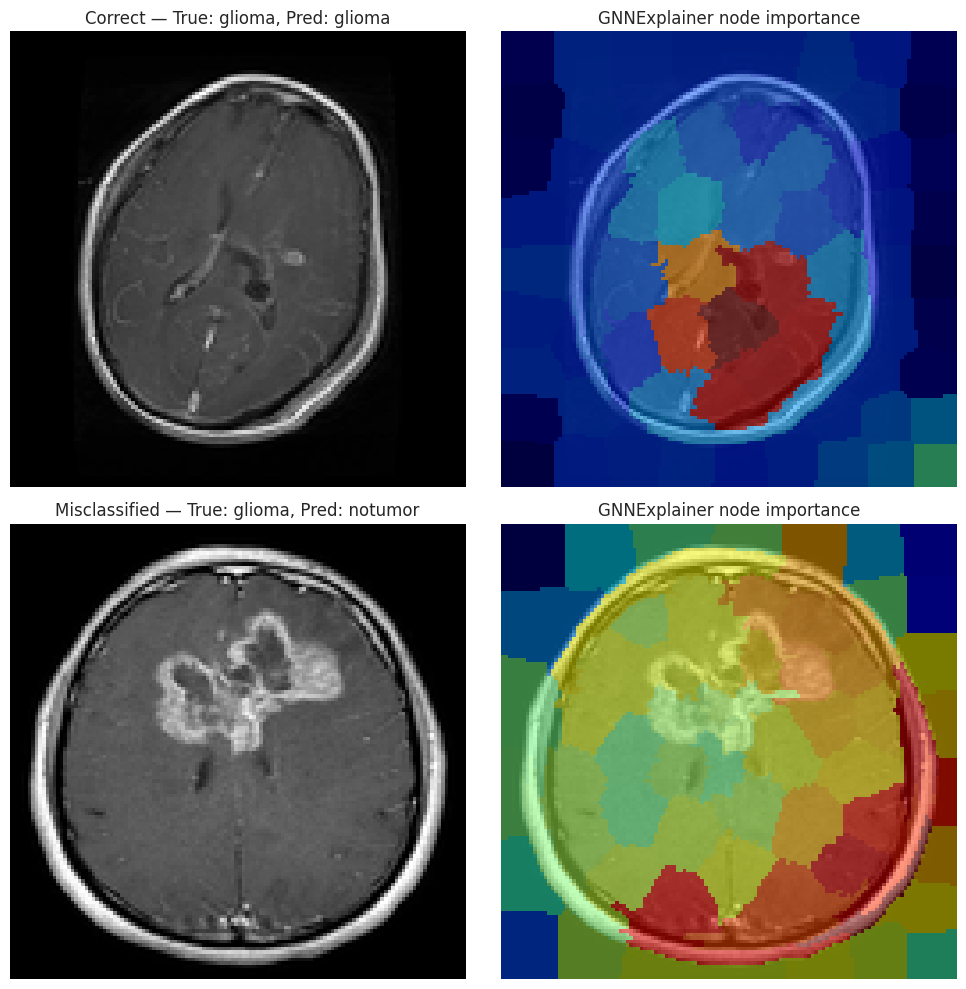

In [10]:
explainer = Explainer(
    model=final_model,
    algorithm=GNNExplainer(epochs=200),
    explanation_type="model",
    node_mask_type="attributes",
    edge_mask_type="object",
    model_config=dict(mode="multiclass_classification", task_level="graph", return_type="raw"),
)

def explain_graph(data, true_idx):
    data = data.to(device)
    explanation = explainer(
        # NOTE: keyword is `edge_weight`, matching BrainTumorGCN.forward()'s parameter
        # name -- not `edge_attr`. Explainer forwards these kwargs straight into the
        # model, so they must match its signature exactly (this was the original bug).
        x=data.x, edge_index=data.edge_index, edge_weight=data.edge_attr,
        batch=torch.zeros(data.x.shape[0], dtype=torch.long, device=device),
    )
    node_importance = explanation.node_mask.sum(dim=1).cpu().numpy()  # per-node importance score

    orig_img = Image.open(data.filepath).convert("L").resize(GRAPH_IMG_SIZE, Image.LANCZOS)
    orig_arr = np.asarray(orig_img, dtype=np.float32) / 255.0
    segments = data.segments

    importance_map = np.zeros_like(orig_arr)
    norm_importance = (node_importance - node_importance.min()) / (node_importance.max() - node_importance.min() + 1e-8)
    for seg_id, score in enumerate(norm_importance):
        importance_map[segments == seg_id] = score

    return orig_arr, importance_map


correct_idx = next(i for i in range(len(graphs_test)) if gcn_y_pred[i] == gcn_y_true[i])
wrong_idx = next((i for i in range(len(graphs_test)) if gcn_y_pred[i] != gcn_y_true[i]), None)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

img, imp = explain_graph(graphs_test[correct_idx], gcn_y_true[correct_idx])
axes[0, 0].imshow(img, cmap="gray"); axes[0, 0].set_title(
    f"Correct — True: {CLASSES[gcn_y_true[correct_idx]]}, Pred: {CLASSES[gcn_y_pred[correct_idx]]}"); axes[0, 0].axis("off")
axes[0, 1].imshow(img, cmap="gray"); axes[0, 1].imshow(imp, cmap="jet", alpha=0.5)
axes[0, 1].set_title("GNNExplainer node importance"); axes[0, 1].axis("off")

if wrong_idx is not None:
    img2, imp2 = explain_graph(graphs_test[wrong_idx], gcn_y_true[wrong_idx])
    axes[1, 0].imshow(img2, cmap="gray"); axes[1, 0].set_title(
        f"Misclassified — True: {CLASSES[gcn_y_true[wrong_idx]]}, Pred: {CLASSES[gcn_y_pred[wrong_idx]]}"); axes[1, 0].axis("off")
    axes[1, 1].imshow(img2, cmap="gray"); axes[1, 1].imshow(imp2, cmap="jet", alpha=0.5)
    axes[1, 1].set_title("GNNExplainer node importance"); axes[1, 1].axis("off")
else:
    axes[1, 0].axis("off"); axes[1, 1].axis("off")
    print("No misclassified test example found.")

plt.tight_layout()
plt.savefig("GCN_explainability_examples.png", dpi=150)
plt.show()

## 10. Results Summary & Saved Outputs

In [11]:
summary = {
    "model_name": "GCN_superpixel",
    "cv_mean_acc": cv_df["val_acc"].mean(),
    "cv_std_acc": cv_df["val_acc"].std(),
    "cv_mean_f1_macro": cv_df["f1_macro"].mean(),
    "cv_std_f1_macro": cv_df["f1_macro"].std(),
    "final_test_accuracy": gcn_test_acc,
    "final_test_f1_macro": report_dict["macro avg"]["f1-score"],
    "cnn_baseline_accuracy": CNN_BASELINE_ACC,
    "accuracy_delta_vs_cnn": gcn_test_acc - CNN_BASELINE_ACC,
}
with open("GCN_results_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("=== Final Comparison ===")
for k, v in summary.items():
    print(f"{k:28s}: {v:.4f}" if isinstance(v, float) else f"{k:28s}: {v}")

print("\nFiles saved this notebook:")
print("  GCN_best_model.pth, GCN_fold{1..5}.pth")
print("  GCN_5fold_cv_results.csv, GCN_final_history.csv, GCN_fold{1..5}_history.csv")
print("  GCN_classification_report.txt/.json, GCN_test_predictions.npy, GCN_test_labels.npy")
print("  GCN_explainability_examples.png, GCN_results_summary.json")
print("  significance_test_results.json (if CNN predictions were provided)")

=== Final Comparison ===
model_name                  : GCN_superpixel
cv_mean_acc                 : 0.7923
cv_std_acc                  : 0.0124
cv_mean_f1_macro            : 0.7959
cv_std_f1_macro             : 0.0144
final_test_accuracy         : 0.7513
final_test_f1_macro         : 0.7341
cnn_baseline_accuracy       : 0.9400
accuracy_delta_vs_cnn       : -0.1887

Files saved this notebook:
  GCN_best_model.pth, GCN_fold{1..5}.pth
  GCN_5fold_cv_results.csv, GCN_final_history.csv, GCN_fold{1..5}_history.csv
  GCN_classification_report.txt/.json, GCN_test_predictions.npy, GCN_test_labels.npy
  GCN_explainability_examples.png, GCN_results_summary.json
  significance_test_results.json (if CNN predictions were provided)
